# Customer Segmentation (Clustering)

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep=None, engine="python")

In [3]:
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

In [4]:
df["Total_Spent"] = df[spending_columns].sum(axis=1)

In [5]:
x_cluster = df[["Income", "Total_Spent"]].dropna()

In [6]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

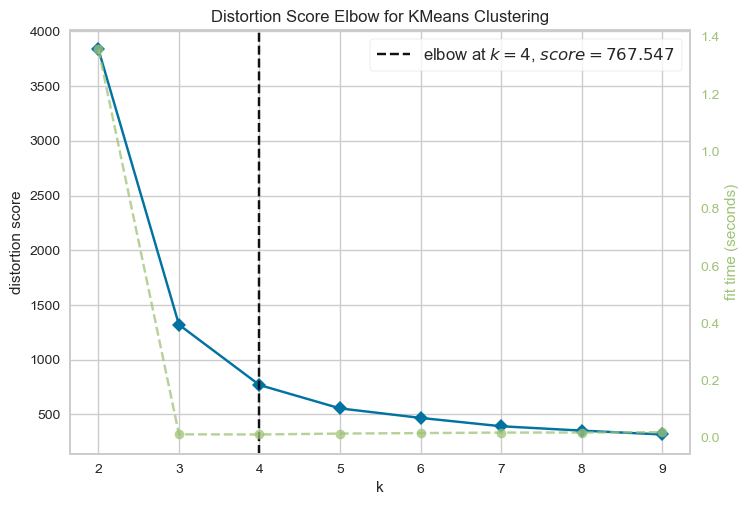

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [7]:
model = KMeans(random_state=42)
vis = KElbowVisualizer(model, k=(2, 10))
vis.fit(x_scaled)
vis.show()

In [8]:
optimal_k = vis.elbow_value_ if vis.elbow_value_ is not None else 4

In [9]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
x_cluster["Cluster"] = clusters

C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


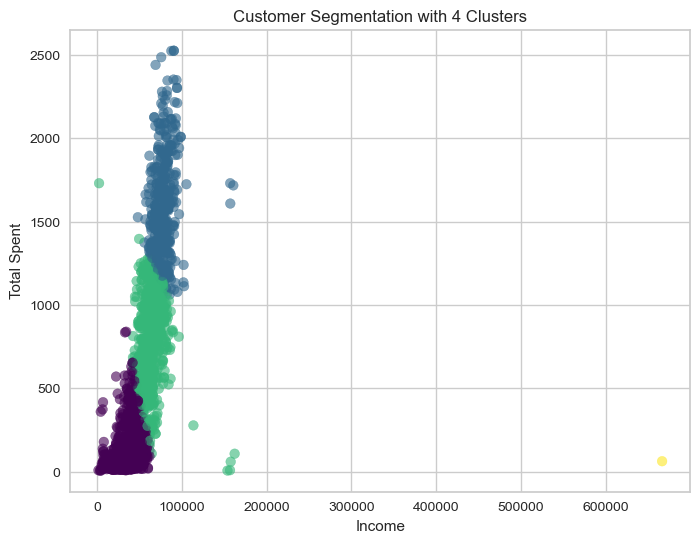

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    x_cluster["Income"],
    x_cluster["Total_Spent"],
    c=x_cluster["Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.title(f"Customer Segmentation with {optimal_k} Clusters")
plt.xlabel("Income")
plt.ylabel("Total Spent")
plt.show()

In [11]:
joblib.dump(kmeans, "clustering_model.pkl")

['clustering_model.pkl']